# Portefeuille des élus du Congrès — spécification mathématique
**Reconstruction, classement, stratégie de copie et ajustement au marché**

Notebook calqué sur `NOTE_MATHS_PORTEFEUILLE_MEMBRE`. Réutilise le pipeline de données du `05`,
avec la **combinaison inter-membres en parts** (NAV continue, buy-and-hold autofinancé — méthode formalisée dans `NOTE_NAV_PORTEFEUILLE_EN_PARTS.md`) et
l'**ajustement par le marché** ($\beta$, $\alpha$, ratio d'appréciation).

Notations : $i$ = ticker, $t$ = jour de bourse, $P_i(t)$ = cours de clôture.

## 0. Données (nettoyage transactionnel fait en amont S1/S2)
Table canonique source-primaire + panel de prix `prices_v2` avec garde-fou anti-corruption Yahoo.

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices_v2")

In [2]:
# Table PROPRE canonique S1/S2 (source-primaire) -> noms alignés sur la mécanique du 05.
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
n0 = len(df)
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")

134464 -> 134429 trades  |  372 membres  |  4618 tickers


In [3]:
print(f"aperçu de la table canonique : 5 des {len(df)} trades (1 ligne = 1 transaction déclarée)")
df.head()

aperçu de la table canonique : 5 des 134429 trades (1 ligne = 1 transaction déclarée)


,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5
3,F000462,Lois Frankel,STJ,buy,2014-12-03,8000.5
4,F000462,Lois Frankel,MMM,sell,2014-12-10,8000.5


In [4]:
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché

In [5]:
# Télécharge les prix ABSENTS du cache (resumable ; cache complet => 0 => hors-ligne)
import yfinance as yf, time, logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)
os.makedirs(PRICES, exist_ok=True)
have0  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
fail_f = os.path.join(PRICES, "failed_v2.csv")
failed = set(pd.read_csv(fail_f)["ticker"]) if os.path.exists(fail_f) else set()
todo   = [t for t in dict.fromkeys(df["ticker"]) if isinstance(t, str) and t not in have0 and t not in failed]
print(f"cache: {len(have0)} tickers | délistés/échecs connus sautés: {len(set(df['ticker']) & failed)} | à télécharger: {len(todo)}")
new_fail = []
for i in range(0, len(todo), 60):
    chunk = todo[i:i+60]
    try:
        data = yf.download(chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                           progress=False, threads=True, group_by="ticker")
    except Exception as e:
        print("  batch KO:", str(e)[:60]); data = None
    for t in chunk:
        s = None
        try:
            if data is not None and isinstance(data.columns, pd.MultiIndex):
                if t in data.columns.get_level_values(0):
                    s = data[t]["Close"].dropna()
            elif data is not None and "Close" in getattr(data, "columns", []):
                s = data["Close"].dropna()
        except Exception:
            s = None
        if s is None or len(s) < 20:
            new_fail.append(t)
        else:
            s.rename("close").to_csv(os.path.join(PRICES, t + ".csv"))
    time.sleep(0.4)
if new_fail:
    pd.DataFrame({"ticker": new_fail, "classe": "inattendu"}).to_csv(fail_f, mode="a", header=False, index=False)
print(f"téléchargés OK: {len(todo) - len(new_fail)} | nouveaux échecs: {len(new_fail)}")

cache: 3351 tickers | délistés/échecs connus sautés: 1268 | à télécharger: 0
téléchargés OK: 0 | nouveaux échecs: 0


In [6]:
# Charge les prix utiles, alignés sur le calendrier ; garde-fou anti-corruption Yahoo
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)
prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()
corrompus = [tk for tk in need if (len(prices[tk].dropna()) < 2
             or prices[tk].dropna().min() < 0.10
             or prices[tk].dropna().pct_change().abs().max() > 3.0)]   # <0,10$ ou saut >300%/j
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]
n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)} | sans prix : {len(missing)} | corrompus exclus : {len(corrompus)} | trades jetés : {n_drop}  => {len(df)} exploitables")

tickers avec prix : 3289 | sans prix : 1268 | corrompus exclus : 61 | trades jetés : 16400  => 118029 exploitables


## 1. Reconstruction du portefeuille d'un membre
- **Achat** $\to$ parts, au 1er jour coté $\ge$ date de transaction : $q = \dfrac{\text{montant}}{P_i(\tau)},\ \tau=\min\{t\ge \texttt{traded}\}$.
- **Vente** $\to$ retire des parts (short interdit) : $q^- = \min(\text{montant}/P_i,\ \text{parts détenues})$.
- **Détentions cumulées** : $n_i(t) = \sum_{\text{achats}\le t} q - \sum_{\text{ventes}\le t} q^-$.
- **Valeur** : $V(t) = \sum_i n_i(t)\,P_i(t)$.

In [7]:
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marché)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

def member_shares(g):
    # g = trades d'un membre  ->  N (parts détenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

In [8]:
# Membre pris en exemple pour TOUTES les illustrations (constante, définie UNE fois ; les démos l'APPLIQUENT).
# ⚠️ filtre par bioguide_id, PAS par nom : certains élus portent plusieurs variantes de nom
#    (ex. « Barbara J. Comstock » ET « Barbara J Honorable Comstock ») -> le nom exact rate des trades.
DEMO = "Barbara J. Comstock"
DEMO_BID = df.loc[df["name"] == DEMO, "bioguide_id"].iloc[0]

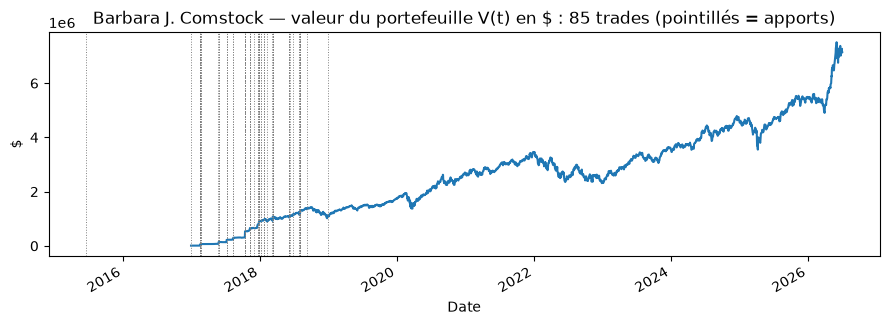

In [9]:
# Démo AUTO-SUFFISANTE : la VALEUR V(t) saute à chaque achat (apports + performance mélangés)
g_demo = df[df["bioguide_id"] == DEMO_BID]
Nm = member_shares(g_demo)
V = (Nm * pd.DataFrame({tk: prices[tk] for tk in Nm.columns})).sum(axis=1)
Va = V[Nm.sum(axis=1) > 0]
ax = Va.plot(figsize=(9, 3.5), color="tab:blue")
for d in g_demo["traded"]:
    ax.axvline(d, color="gray", ls=":", lw=0.7)
ax.set_title(f"{DEMO} — valeur du portefeuille V(t) en $ : {len(g_demo)} trades (pointillés = apports)")
ax.set_ylabel("$"); plt.tight_layout(); plt.show()

In [10]:
# Démo AUTO-SUFFISANTE : le tableau N des parts détenues n_i(t), une colonne par ticker
Nm = member_shares(df[df["bioguide_id"] == DEMO_BID])
actifs = Nm[Nm.sum(axis=1) > 0]
ech = actifs.iloc[::max(1, len(actifs) // 8)].round(1)
print(f"{DEMO} — parts détenues n_i(t) : {actifs.shape[1]} tickers, {len(actifs)} jours actifs ({len(ech)} lignes échantillonnées)")
ech

Barbara J. Comstock — parts détenues n_i(t) : 41 tickers, 2390 jours actifs (9 lignes échantillonnées)


,AAPL,ALNY,AMBA,AMZN,BA,CIBR,EMB,F,GRPN,HPE,...,VEA,VFH,VGT,VHT,VNQ,VO,VTV,VUG,VWO,XT
Date,,,,,,,,,,,,,,,,,,,,,
2016-12-28,297.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-03-07,7836.1,4.9,0.0,0.0,115.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,0.0,0.0,7449.1
2019-05-14,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2020-07-20,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2021-09-23,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2022-11-29,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2024-02-07,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2025-04-16,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2026-06-25,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1


## 2. Rendement d'un membre (*time-weighted*)
On valorise les parts de la **veille** $\Rightarrow$ un apport n'est jamais un rendement :
$$r_P(t) = \frac{\sum_i n_i(t-1)P_i(t)}{\sum_i n_i(t-1)P_i(t-1)} - 1$$
- Jour sans position : $r_P(t)=0$ (système ouvert). Winsorisation $\pm50\,\%$/jour.
- $\mathrm{NAV}(t)=\prod_{s\le t}(1+r_P(s))$ : la **performance pure** (contrairement à $V(t)$ qui mélange les apports).

In [11]:
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Σ n_i(t-1) P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Σ n_i(t-1) P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # winsorisation ±50 %/jour
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

### Aperçu TOTAL : tous les membres d'un coup
On calcule la série de rendement de **chaque** membre une seule fois (réutilisée partout ensuite).
`member_shares`/`daily_return` sont cumulatifs $\Rightarrow$ tronquer à une date ne regarde jamais le futur.

In [12]:
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


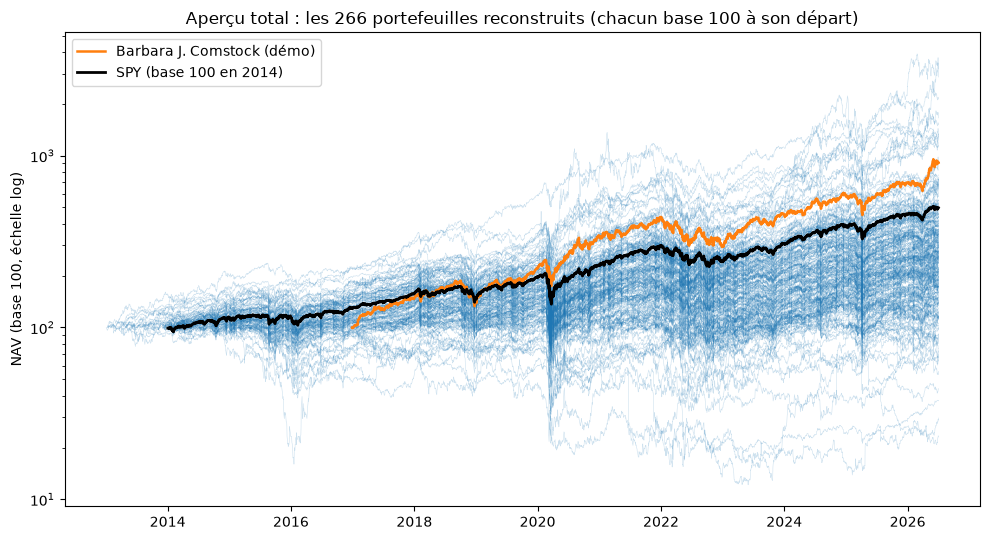

In [13]:
# VISUEL : la NAV de CHAQUE membre (base 100 à son premier jour actif), SPY en noir, démo en orange
plt.figure(figsize=(10, 5.5))
for bid, r in wf_ret.items():
    nav = 100 * (1 + r).cumprod()
    plt.plot(nav.index, nav.values, lw=0.4, alpha=0.22, color="tab:blue")
nav_demo = 100 * (1 + wf_ret[DEMO_BID]).cumprod()
plt.plot(nav_demo.index, nav_demo.values, lw=1.8, color="tab:orange", label=f"{DEMO} (démo)")
cal14 = cal[cal >= "2014-01-01"]
nav_spy = 100 * (1 + r_spy.reindex(cal14).fillna(0)).cumprod()
plt.plot(nav_spy.index, nav_spy.values, lw=2.0, color="k", label="SPY (base 100 en 2014)")
plt.yscale("log"); plt.ylabel("NAV (base 100, échelle log)")
plt.title(f"Aperçu total : les {len(wf_ret)} portefeuilles reconstruits (chacun base 100 à son départ)")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
# La distribution des stats sur TOUS les membres (le tableau de la population)
apercu = pd.DataFrame([{**stats(r), "n_days": len(r)} for r in wf_ret.values()])
print(f"la population : quartiles des stats des {len(apercu)} membres reconstruits")
apercu.describe().loc[["mean", "25%", "50%", "75%"]].round(3)

la population : quartiles des stats des 266 membres reconstruits


,cagr,vol,sharpe,maxdd,n_days
mean,0.146,0.254,0.683,-0.397,2078.812
25%,0.090,0.179,0.533,-0.460,1345.750
50%,0.128,0.216,0.706,-0.364,2270.000
75%,0.172,0.282,0.863,-0.310,3039.500


## 3. Qui est éligible ?
Un ratio de performance n'a de sens que sur assez de matière — un IR calculé sur 3 trades explose
(l'écart-type est minuscule) et ne veut rien dire. On ne garde donc que les membres avec :
$$n_{\text{trades}} \ge 10 \quad\text{et}\quad n_{\text{jours}} \ge 126\ (\sim 6\ \text{mois}).$$

In [15]:
# Éligibilité PURE (pas encore d'IR) : on part des séries de rendement déjà calculées (wf_ret)
MIN_TRADES, MIN_DAYS = 10, 126
tab = pd.DataFrame([dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=len(wf_traded[bid]), n_days=len(r))
                    for bid, r in wf_ret.items()])
elig = tab[(tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)].copy()
M = len(elig)
print(f"{len(tab)} membres avec historique -> {M} éligibles (>= {MIN_TRADES} trades ET >= {MIN_DAYS} jours)")

266 membres avec historique -> 223 éligibles (>= 10 trades ET >= 126 jours)


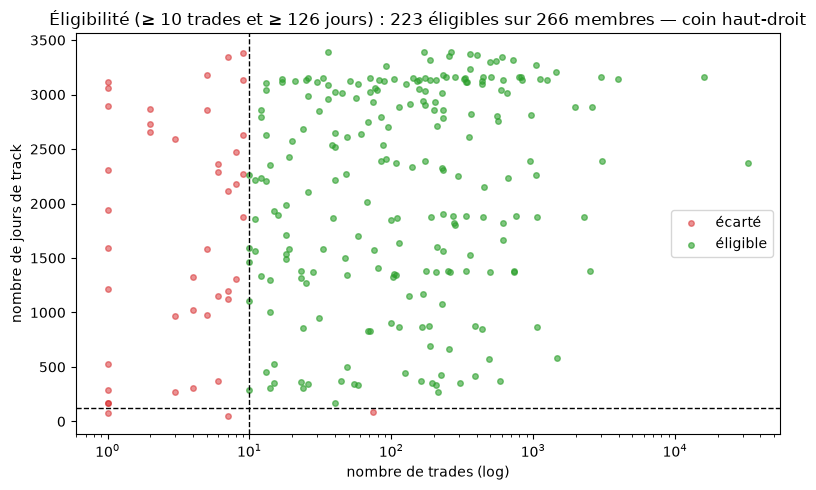

In [16]:
# VISUEL : qui passe la porte ? (n_trades en log x n_jours, la boîte d'éligibilité)
ok = (tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)
plt.figure(figsize=(8, 5))
plt.scatter(tab.n_trades[~ok], tab.n_days[~ok], s=16, alpha=0.5, color="tab:red", label="écarté")
plt.scatter(tab.n_trades[ok], tab.n_days[ok], s=16, alpha=0.6, color="tab:green", label="éligible")
plt.axvline(MIN_TRADES, color="k", ls="--", lw=1); plt.axhline(MIN_DAYS, color="k", ls="--", lw=1)
plt.xscale("log"); plt.xlabel("nombre de trades (log)"); plt.ylabel("nombre de jours de track")
plt.title(f"Éligibilité (≥ {MIN_TRADES} trades et ≥ {MIN_DAYS} jours) : {M} éligibles sur {len(tab)} membres — coin haut-droit")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Qui bat le SPY — talent ou style ?
Deux critères, testés de la même façon (test $t$ unilatéral, seuil $1{,}645$) :

**Information Ratio** (suppose $\beta=1$) :
$$x(t)=r_P(t)-r_{SPY}(t),\quad \mathrm{IR}=\frac{\overline{x}}{\sigma(x)}\sqrt{252},\quad t=\mathrm{IR}\sqrt{n/252}$$

**Appraisal** (talent, marché retiré) — régression $r_P=\alpha+\beta\,r_{SPY}+\varepsilon$ :
$$\beta=\frac{\mathrm{Cov}(r_P,r_{SPY})}{\mathrm{Var}(r_{SPY})},\ \ \alpha=\overline{r_P}-\beta\,\overline{r_{SPY}},\ \ \text{appraisal}=\frac{\alpha}{\sigma(\varepsilon)}\sqrt{252},\ \ t_{\text{appr}}=\text{appraisal}\sqrt{n/252}$$

$\beta=1 \Rightarrow$ appraisal $=$ IR ; sinon l'IR mélange **exposition** (style) et **talent**.
⚠️ Sur $M=223$ tests **corrélés** (mêmes tickers, mêmes périodes), $\sim 11$ dépassements du seuil sont
attendus par pur hasard — et c'est une **borne basse** de l'incertitude (les tests ne sont pas indépendants).

In [17]:
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

def alpha_beta(r):
    """Régression r = alpha + beta*r_spy + eps -> beta, alpha annualisé, appraisal, t_appr."""
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, appraisal=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)      # pente, ordonnée
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = (alpha / se * np.sqrt(252)) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, appraisal=appr,
                t_appr=appr * np.sqrt(len(d) / 252))

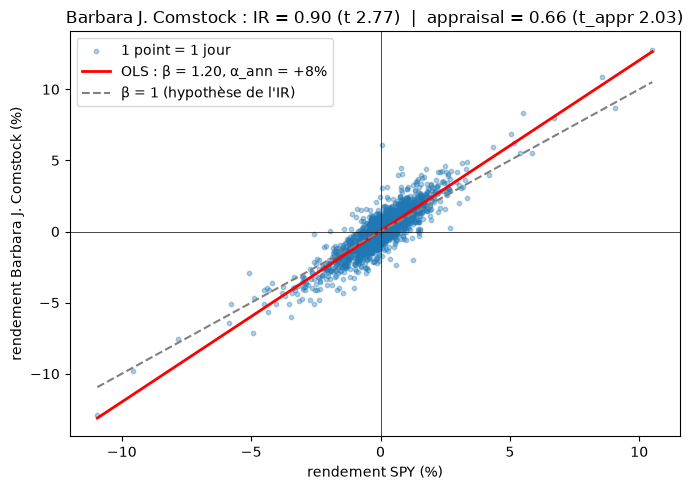

In [18]:
# Illustration AUTO-SUFFISANTE : la régression du membre démo décompose r_P en beta*SPY + alpha (+ résidu)
rm = daily_return(member_shares(df[df["bioguide_id"] == DEMO_BID]))
d = pd.concat([rm.rename("y"), r_spy.reindex(rm.index).rename("x")], axis=1).dropna()
beta, alpha = np.polyfit(d["x"], d["y"], 1)
ab = alpha_beta(rm)
ir = info_ratio(rm); t_ir = ir * np.sqrt(len(rm) / 252)
plt.figure(figsize=(7, 5))
plt.scatter(d["x"] * 100, d["y"] * 100, s=10, alpha=0.35, label="1 point = 1 jour")
xs = np.linspace(d["x"].min(), d["x"].max(), 50)
plt.plot(xs * 100, (alpha + beta * xs) * 100, color="red", lw=2,
         label=f"OLS : β = {beta:.2f}, α_ann = {ab['alpha_ann']:+.0%}")
plt.plot(xs * 100, xs * 100, color="gray", ls="--", label="β = 1 (hypothèse de l'IR)")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.xlabel("rendement SPY (%)"); plt.ylabel(f"rendement {DEMO} (%)")
plt.title(f"{DEMO} : IR = {ir:.2f} (t {t_ir:.2f})  |  appraisal = {ab['appraisal']:.2f} (t_appr {ab['t_appr']:.2f})")
plt.legend(); plt.tight_layout(); plt.show()

### 4.1 Classement par l'IR
On classe les éligibles par IR et on garde les significatifs ($t>1{,}645$).

In [19]:
elig["IR"] = [info_ratio(wf_ret[b]) for b in elig.bioguide_id]
elig["t"]  = elig.IR * np.sqrt(elig.n_days / 252)
sig = elig[elig.t > 1.645]
print(f"les {len(sig)} membres significatifs par l'IR (t > 1,645) sur {M} éligibles, classés par IR — ~{0.05*M:.0f} attendus par pur hasard")
COLS_IR = ["name", "n_trades", "n_days", "IR", "t"]
sig.sort_values("IR", ascending=False).head(20)[COLS_IR].round(3).reset_index(drop=True)   # tous les significatifs

les 20 membres significatifs par l'IR (t > 1,645) sur 223 éligibles, classés par IR — ~11 attendus par pur hasard


,name,n_trades,n_days,IR,t
0,John Fetterman,10,284,2.482,2.635
1,Ashley Moody,23,364,1.670,2.007
2,Morgan McGarvey,24,853,1.502,2.764
3,Lisa McClain,1479,580,1.264,1.917
4,Daniel S Sullivan,100,904,0.999,1.892
5,Thomas Suozzi,662,2230,0.902,2.683
6,Barbara J. Comstock,85,2390,0.899,2.769
7,MARK R WARNER,15,1934,0.800,2.218
8,David Kustoff,10,1595,0.793,1.994
9,Ron L Wyden,231,1568,0.770,1.920


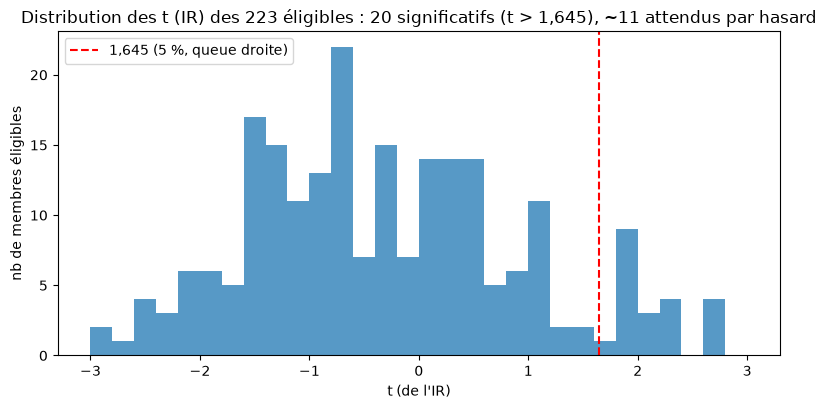

In [20]:
# FIGURE IR (style de référence, copié tel quel en 4.2) : distribution des t
BINS_T = np.linspace(-3, 3, 31)
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t.dropna(), bins=BINS_T, alpha=0.75, color="tab:blue")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'IR)"); plt.ylabel("nb de membres éligibles")
plt.title(f"Distribution des t (IR) des {M} éligibles : {len(sig)} significatifs (t > 1,645), ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 Classement par l'appraisal
Exactement la même chose, mais sur le **talent** (β retiré) : on classe par appraisal, on garde $t_{\text{appr}}>1{,}645$.

In [21]:
abdf = pd.DataFrame([alpha_beta(wf_ret[b]) for b in elig.bioguide_id], index=elig.index)
elig = pd.concat([elig, abdf], axis=1)          # ajoute beta / alpha_ann / appraisal / t_appr
sig_appr = elig[elig.t_appr > 1.645]
print(f"les {len(sig_appr)} membres significatifs par l'appraisal (t_appr > 1,645) sur {M} éligibles, classés par appraisal — ~{0.05*M:.0f} attendus par pur hasard")
COLS_APPR = ["name", "n_trades", "n_days", "appraisal", "t_appr"]
sig_appr.sort_values("appraisal", ascending=False).head(12)[COLS_APPR].round(3).reset_index(drop=True)   # tous les significatifs

les 12 membres significatifs par l'appraisal (t_appr > 1,645) sur 223 éligibles, classés par appraisal — ~11 attendus par pur hasard


,name,n_trades,n_days,appraisal,t_appr
0,John Fetterman,10,284,2.242,2.380
1,Morgan McGarvey,24,853,1.081,1.988
2,Raul Ruiz,10,2261,0.802,2.401
3,Trey Hollingsworth,18,1494,0.790,1.924
4,Barbara J. Comstock,85,2390,0.659,2.030
5,MARK R WARNER,15,1934,0.649,1.797
6,Brian Babin,20,2573,0.624,1.995
7,Thomas Suozzi,662,2230,0.589,1.752
8,Pete Sessions,361,3376,0.550,2.013
9,Suzan K. DelBene,157,3054,0.521,1.813


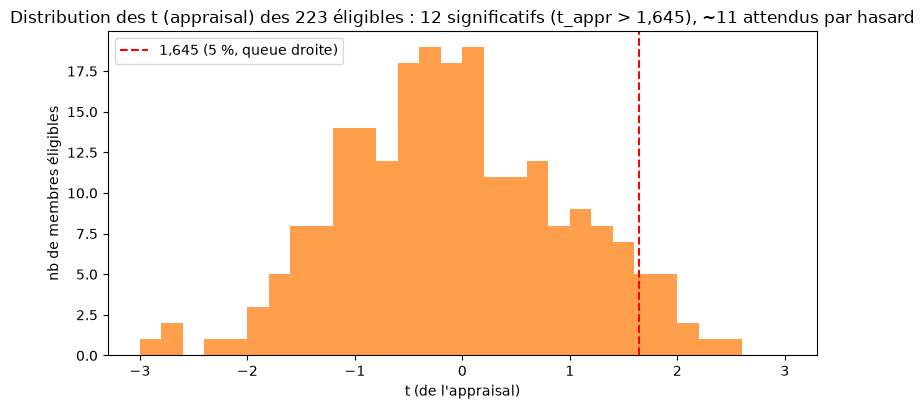

In [22]:
# FIGURE APPRAISAL (copie EXACTE du style de 4.1) : distribution des t_appr
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t_appr.dropna(), bins=BINS_T, alpha=0.75, color="tab:orange")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'appraisal)"); plt.ylabel("nb de membres éligibles")
plt.title(f"Distribution des t (appraisal) des {M} éligibles : {len(sig_appr)} significatifs (t_appr > 1,645), ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.3 Le lien entre les deux
L'IR et l'appraisal ne diffèrent que par le **β**. Chaque point ci-dessous : son IR (vertical) contre
son appraisal (horizontal), coloré par β.

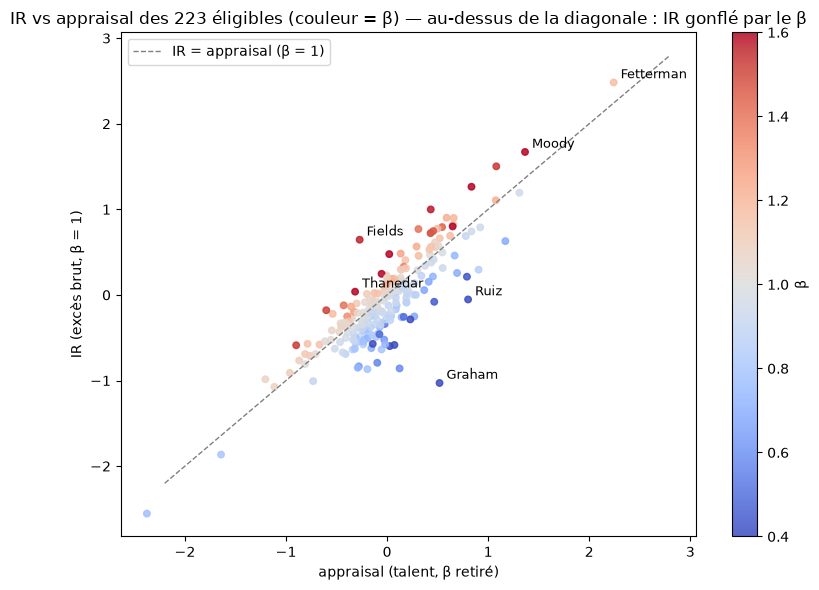

In [23]:
# FIGURE LIEN (le seul endroit où le beta paraît) : IR vs appraisal, couleur = beta
plt.figure(figsize=(8, 6))
sc = plt.scatter(elig.appraisal, elig.IR, c=elig.beta, cmap="coolwarm", vmin=0.4, vmax=1.6, s=22, alpha=0.85)
plt.colorbar(sc, label="β")
lim = [-2.2, 2.8]
plt.plot(lim, lim, color="gray", ls="--", lw=1, label="IR = appraisal (β = 1)")
for pat in ["Fetterman", "Moody", "Thanedar", "Fields", "Graham", "Ruiz"]:
    m = elig[elig.name.str.contains(pat, na=False)]
    if len(m):
        row = m.iloc[0]
        plt.annotate(pat, (row.appraisal, row.IR), fontsize=9, xytext=(5, 3), textcoords="offset points")
plt.xlabel("appraisal (talent, β retiré)"); plt.ylabel("IR (excès brut, β = 1)")
plt.title(f"IR vs appraisal des {M} éligibles (couleur = β) — au-dessus de la diagonale : IR gonflé par le β")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Choisir qui copier chaque année (walk-forward, point-in-time)
À chaque fin d'année $Y$, on classe les éligibles par un **critère** et on garde les significatifs :
$$\mathrm{classement}(Y)=\{\text{éligibles}\ \wedge\ t_{\text{crit}}>1{,}645\}\ \text{triés par le critère},$$
top-$K$ suivi en $Y{+}1$. Aucun regard vers le futur : $n_i(t)$ ne dépend que des trades $\le t$.
Même mécanique pour les **deux** critères (IR, appraisal) ; le choix du critère est étudié en §6.

In [24]:
def classement_a_fin(Y, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """Classement point-in-time au 31/12/Y. critere = "ir" (excès/SPY) ou "appraisal" (régression β)."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:yend]
        n_trades = int((wf_traded[bid] <= yend).sum())
        n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252)
            t = score * np.sqrt(n_days / 252)
        else:                                            # appraisal : régression sur le seul passé <= Y
            ab = alpha_beta(rr)
            score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=n_trades, n_days=n_days, score=score, t=t))
    cols = ["bioguide_id", "name", "n_trades", "n_days", "score", "t"]
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=cols))

# Les DEUX caches co-définis ici (jamais de sélection avant que son cache existe)
clsmt    = {Y: classement_a_fin(Y, critere="ir")        for Y in range(2014, 2027)}
clsmt_ap = {Y: classement_a_fin(Y, critere="appraisal") for Y in range(2014, 2027)}

def select_topK(Y, K, critere="ir"):
    cache = clsmt if critere == "ir" else clsmt_ap
    c = cache[Y] if Y in cache else classement_a_fin(Y, critere=critere)
    return list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
print("classements point-in-time prêts (IR et appraisal, 2014-2026)")

classements point-in-time prêts (IR et appraisal, 2014-2026)


In [25]:
# TABLE SYMÉTRIQUE : nb de significatifs et tête du classement, par critère, à chaque coupe
def _tete(c): return c.name.iloc[0].split()[-1] if len(c) else "-"
resume = pd.DataFrame([
    dict(fenetre=f"2014-{Y}", n_sig_IR=len(clsmt[Y]), n_sig_appr=len(clsmt_ap[Y]),
         tete_IR=_tete(clsmt[Y]), tete_appr=_tete(clsmt_ap[Y]))
    for Y in range(2014, 2027)])
print(f"les {len(resume)} coupes annuelles 2014-2026 : nb de significatifs et tête du classement, par critère")
resume

les 13 coupes annuelles 2014-2026 : nb de significatifs et tête du classement, par critère


,fenetre,n_sig_IR,n_sig_appr,tete_IR,tete_appr
0,2014-2014,1,3,Reed,Reed
1,2014-2015,4,4,McKinley,Chabot
2,2014-2016,2,4,Long,Brooks
3,2014-2017,4,4,Comstock,Khanna
4,2014-2018,5,7,Heck,Heck
5,2014-2019,8,11,Evans,Lee
6,2014-2020,19,21,Beyer,Beyer
7,2014-2021,13,10,Comstock,Heck
8,2014-2022,7,7,DelBene,Coble
9,2014-2023,12,12,Landsman,Sullivan


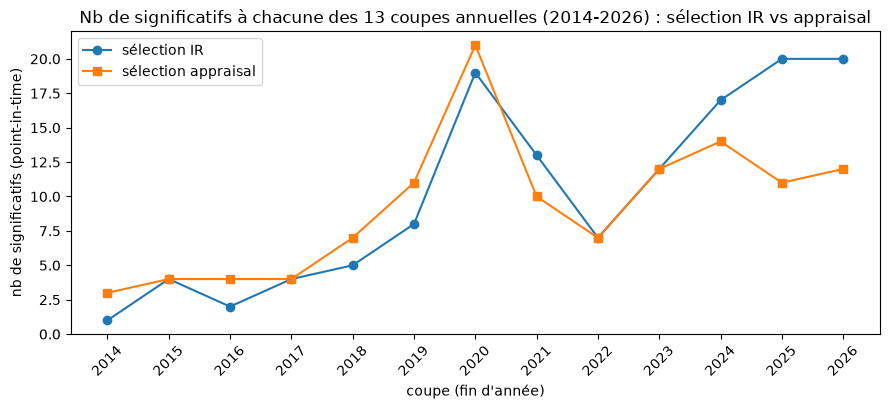

In [26]:
# FIGURE SYMÉTRIQUE : nb de significatifs par an, IR vs appraisal
annees = list(range(2014, 2027))
plt.figure(figsize=(9, 4.2))
plt.plot(annees, [len(clsmt[Y]) for Y in annees], marker="o", label="sélection IR")
plt.plot(annees, [len(clsmt_ap[Y]) for Y in annees], marker="s", label="sélection appraisal")
plt.xticks(annees, [str(y) for y in annees], rotation=45)
plt.ylabel("nb de significatifs (point-in-time)"); plt.xlabel("coupe (fin d'année)")
plt.title(f"Nb de significatifs à chacune des {len(annees)} coupes annuelles (2014-2026) : sélection IR vs appraisal")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Le portefeuille de copy-trading top-$K$ (sélection IR ∥ appraisal) : bat-il le SPY ?

### 6.1 La construction en parts
**Ingrédients.** Coupes de rebalancement $t^R_Y$ = dernier jour coté de l'année $Y$
($Y=2015,\dots,2025$) ; sélection $\mathcal{S}_Y$ = top-$K$ du classement point-in-time à la
coupe (§5) ; poids cibles $w_k=\frac1K$, $\sum_{k\in\mathcal{S}_Y} w_k=1$ ; richesse initiale
$W(t^R_{2015})=100$.

**Chaque membre $k$ = un fonds**, dont le prix de part est sa NAV (rendement $r_k$ du §2) :
$$\mathrm{NAV}^k(t)=\prod_{s\le t}\big(1+r_k(s)\big)$$

**L'état du portefeuille = ses nombres de parts** $\mathrm{nbr}^k_Y$. À chaque coupe $t^R_Y$,
en fin de journée : (i) on **compte** la richesse disponible avec les anciennes parts, aux prix
du jour ; (ii) on la **redéploie** selon les poids cibles :
$$\text{(i)}\quad W(t^R_Y)=\!\!\sum_{k\in\mathcal{S}_{Y-1}}\!\!\mathrm{nbr}^k_{Y-1}\,\mathrm{NAV}^k(t^R_Y)
\qquad\qquad
\text{(ii)}\quad \mathrm{nbr}^k_Y=\frac{w_k\,W(t^R_Y)}{\mathrm{NAV}^k(t^R_Y)},\quad k\in\mathcal{S}_Y$$

**Entre deux coupes** ($t^R_Y<t\le t^R_{Y+1}$), les parts ne bougent pas — c'est le buy-and-hold :
$$\mathrm{NAV}(t)=\!\!\sum_{k\in\mathcal{S}_Y}\!\!\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t)
\qquad\Longrightarrow\qquad
\boxed{\;r_{\text{strat}}(t)=\frac{\mathrm{NAV}(t)}{\mathrm{NAV}(t-1)}-1\;}$$

**Deux propriétés.**
- **Autofinancement** : $\sum_{k\in\mathcal{S}_Y}\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t^R_Y)=W(t^R_Y)$
  (car $\sum_k w_k=1$) $\Rightarrow$ la NAV est **continue** à chaque coupe — aucun apport, aucun
  retrait, on ne fait que réallouer.
- **Poids effectifs dérivants** : $w_k(t)=\dfrac{\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t)}{\mathrm{NAV}(t)}
  \ne w_k$ dès le lendemain de la coupe. Les figer — $r_{\text{strat}}(t)=\sum_k w_k\,r_k(t)$ —
  serait un rebalancement quotidien caché ($t$ $1{,}14\to0{,}94$ une fois corrigé).

(Écriture équivalente sur NAV rebasées $N(t)=\sum_k w_k\,\mathrm{NAV}_k(t)$ : voir
`05b_Archives.ipynb`, avec la preuve d'équivalence.)

In [27]:
# Le prix de part de chaque membre-fonds, calculé UNE FOIS sur tout le calendrier
NAVK = pd.DataFrame({bid: (1 + r.reindex(cal).fillna(0.0)).cumprod() for bid, r in wf_ret.items()})

def _parts_engine(blocs, W0=100.0):
    """blocs = [(jours tenus, bids, poids initiaux)] chronologiques -> dict r / nav / journal."""
    W, rets, navs, journal = W0, [], [], []
    for idx, bids, w in blocs:
        tR = cal[cal.get_loc(idx[0]) - 1]                  # coupe = veille du 1er jour tenu (fin de journée)
        nbr = pd.Series(w * W / NAVK.loc[tR, bids].values, index=bids)   # nbr^k = w^k·NAV^avl / NAV^k(tR)
        nav = NAVK.loc[idx, bids].mul(nbr, axis=1).sum(axis=1)           # NAV(t) = Σ nbr^k·NAV^k(t)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] / W - 1                    # 1er jour : contre la richesse redéployée
        journal.append(dict(rebal=tR, nbr=nbr, W_avant=W, W_apres=float(nav.iloc[-1])))
        W = float(nav.iloc[-1])                            # autofinancement -> coupe suivante
        rets.append(r); navs.append(nav)
    return dict(r=pd.concat(rets).sort_index(), nav=pd.concat(navs).sort_index(), journal=journal)

def _poids(sel, mode):
    if mode == "equal":
        return np.ones(len(sel)) / len(sel)
    sc = np.array([s for s, _ in sel])
    return sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)

def strategie_en_parts(K, mode="equal", critere="ir", cadence="annuel"):
    """Sélections annuelles (§5) ou semestrielles ("6m" : requiert clsmt6_*/cuts/next_bound du §8), combinées en PARTS."""
    blocs = []
    if cadence == "annuel":
        for Y in range(2015, 2026):
            sel = select_topK(Y, K, critere=critere)
            idx = cal[cal.year == (Y + 1)]
            if sel and len(idx):
                blocs.append((idx, [b for _, b in sel], _poids(sel, mode)))
    else:                                                  # "6m" : coupes 30/06 & 31/12 du §8
        cache = clsmt6_ir if critere == "ir" else clsmt6_ap
        for d in cuts:
            c = cache[d]
            if len(c) == 0:
                continue
            sel = list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
            idx = cal[(cal > d) & (cal <= next_bound(d))]
            if len(idx):
                blocs.append((idx, [b for _, b in sel], _poids(sel, mode)))
    return _parts_engine(blocs)

print(f"moteur en parts prêt | {NAVK.shape[1]} fonds-membres")

moteur en parts prêt | 266 fonds-membres


### 6.2 L'évaluation
**Excès par année civile** (1 année = 1 observation), avec $G_Y(r)=\prod_{t\in Y}\big(1+r(t)\big)$ :
$$x_Y=G_Y(r_{\text{strat}})-G_Y(r_{\text{SPY}}),\qquad
\mathrm{IR}_{\text{ann}}=\frac{\overline{x}}{\sigma(x)},\qquad t=\mathrm{IR}_{\text{ann}}\sqrt{n}$$
Seuil unilatéral 5 % : $t_{10}\approx 1{,}81$ pour $n=11$ années.

**Ajustement au marché** — la régression du §4, appliquée à la série de la stratégie :
$$r_{\text{strat}}(t)=\alpha+\beta\,r_{\text{SPY}}(t)+\varepsilon(t),\qquad
\alpha_{\text{ann}}=(1+\alpha)^{252}-1$$
Si $\beta>1$, une part de l'excès brut n'est que de l'exposition au marché : $\alpha<$ excès brut.

In [28]:
# Évaluation par années civiles (1 année = 1 observation) + LA série de référence, calculée UNE fois
def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: ((1 + r[r.index.year == y]).prod() - 1) - ((1 + b[r.index.year == y]).prod() - 1)
                      for y in sorted(set(r.index.year))})

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

def _ligne(r):
    e = eval_yearly(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_moyen"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

det4    = strategie_en_parts(4, "equal", "ir")   # dict r / nav / journal — réutilisé par le zoom et la figure
r_dr_eq = det4["r"]
r_ap_eq = strategie_en_parts(4, "equal", "appraisal")["r"]   # 2e série de référence, réutilisée aux §7-§8
print(f"évaluation annuelle prête | séries top-4 (sélection IR et appraisal) : {len(yearly_excess(r_dr_eq))} années de tenue (2016-2026)")

évaluation annuelle prête | séries top-4 (sélection IR et appraisal) : 11 années de tenue (2016-2026)


### 6.3 Le résultat top-4
Le cas de référence : $K=4$, poids $1/4$, rebalancement annuel (2016-2026).
D'abord les **parts en action** à une coupe, puis les métriques, puis la NAV. Le choix de $K$ vient au §7.

In [29]:
# LES PARTS EN ACTION : la coupe fin 2020 -> tenue 2021 (top-4 sél IR)
j_av, j_ap = [(a, b) for a, b in zip(det4["journal"], det4["journal"][1:])
              if b["rebal"].year == 2020][0]
tR = j_ap["rebal"]; nom = lambda b: df.loc[df.bioguide_id == b, "name"].iloc[0]
tous = j_av["nbr"].index.union(j_ap["nbr"].index)
zoom = pd.DataFrame({
    "parts avant (tenue 2020)": j_av["nbr"].reindex(tous).fillna(0.0),
    "parts après (tenue 2021)": j_ap["nbr"].reindex(tous).fillna(0.0),
    "prix de part NAV^k(tR)":   NAVK.loc[tR, tous],
})
zoom["valeur avant"] = zoom["parts avant (tenue 2020)"] * zoom["prix de part NAV^k(tR)"]
zoom["valeur après"] = zoom["parts après (tenue 2021)"] * zoom["prix de part NAV^k(tR)"]
zoom.index = [nom(b) for b in tous]
assert abs(zoom["valeur avant"].sum() - zoom["valeur après"].sum()) < 1e-9 * j_ap["W_avant"]
print(f"les parts en action (top-4 sél IR) — coupe du {tR.date()} : on compte {j_ap['W_avant']:.2f} avec les ANCIENNES parts, "
      f"on redéploie {zoom['valeur après'].sum():.2f} aux nouveaux poids — autofinancement, la NAV ne saute pas")
zoom.round(3)

les parts en action (top-4 sél IR) — coupe du 2020-12-31 : on compte 245.93 avec les ANCIENNES parts, on redéploie 245.93 aux nouveaux poids — autofinancement, la NAV ne saute pas


,parts avant (tenue 2020),parts après (tenue 2021),prix de part NAV^k(tR),valeur avant,valeur après
Donald Sternoff Beyer,0.000,40.087,1.534,0.000,61.483
Barbara J. Comstock,20.778,18.031,3.410,70.849,61.483
Gilbert Cisneros,0.000,32.957,1.866,0.000,61.483
Dwight Evans,21.984,0.000,2.512,55.219,0.000
Denny Heck,24.334,0.000,2.353,57.265,0.000
Thomas Suozzi,28.631,0.000,2.186,62.598,0.000
MARK R WARNER,0.000,7.749,7.935,0.000,61.483


In [30]:
# LA comparaison : 2 colonnes symétriques (IR vs appraisal), métriques en lignes, tout formaté
def _col(r):
    e = eval_yearly(r); a = alpha_beta(r)
    fr = lambda x, f: format(x, f).replace("-", "−").replace(".", ",")
    return {"excès/an":         fr(e["exces_moyen"], "+.1%"),
            "t":                 fr(e["t"], ".2f"),
            "années gagnantes":  e["gagnantes"],
            "β":                 fr(a["beta"], ".2f"),
            "α annualisé":       fr(a["alpha_ann"], "+.1%"),
            "t (appraisal)":     fr(a["t_appr"], ".2f")}
print(f"top-4 (poids 1/4, rebalancement annuel) — {len(yearly_excess(r_dr_eq))} années civiles, seuil t₁₀ ≈ 1,81 : sélection IR vs appraisal")
pd.DataFrame({"sélection IR": _col(r_dr_eq), "sélection appraisal": _col(r_ap_eq)})

top-4 (poids 1/4, rebalancement annuel) — 11 années civiles, seuil t₁₀ ≈ 1,81 : sélection IR vs appraisal


,sélection IR,sélection appraisal
excès/an,"+3,1%","−2,5%"
t,"0,94","−1,24"
années gagnantes,7/11,3/11
β,"1,20","1,01"
α annualisé,"−0,4%","−2,3%"
t (appraisal),"−0,13","−0,75"


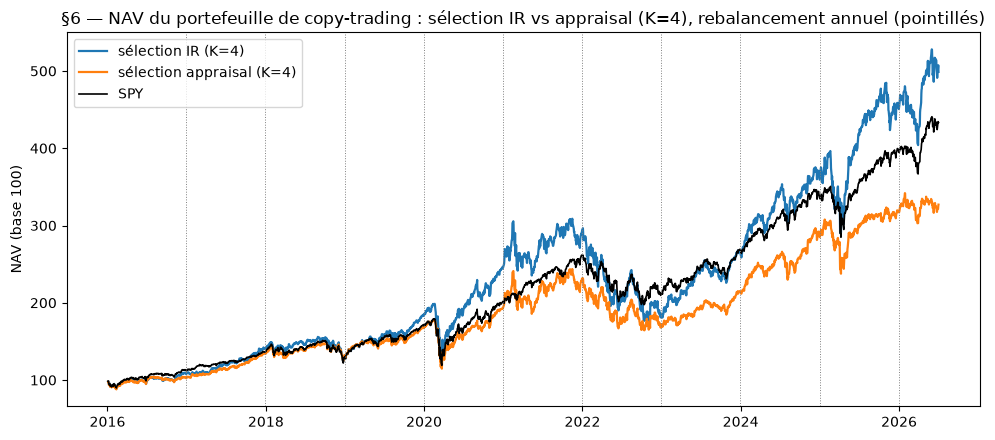

In [31]:
# FIGURE : NAV du portefeuille de copy-trading (base 100) — sélection IR vs appraisal (K=4)
nav_ir = 100 * (1 + r_dr_eq).cumprod()
nav_ap = 100 * (1 + r_ap_eq).cumprod()
nav_sp = 100 * (1 + r_spy.reindex(nav_ir.index).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_ir, label="sélection IR (K=4)", lw=1.6)
plt.plot(nav_ap, label="sélection appraisal (K=4)", lw=1.6)
plt.plot(nav_sp, label="SPY", color="k", lw=1.2)
for j in det4["journal"][1:]:
    plt.axvline(j["rebal"], color="gray", ls=":", lw=0.7)          # rebalancements : la NAV en parts reste continue
plt.ylabel("NAV (base 100)")
plt.title("§6 — NAV du portefeuille de copy-trading : sélection IR vs appraisal (K=4), rebalancement annuel (pointillés)")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Combien copier ? (le choix de $K$)
On construit les stratégies pour tout $K\in[4,20]$, puis on choisit $K$ **honnêtement** (sans regard
futur), avec **le critère de la sélection lui-même** :
$$K^*(Y)=\arg\max_K \;\mathrm{score}_{\text{crit}}\big(\text{strat-}K\big|_{\le Y}\big),\quad
\mathrm{score}_{\text{crit}}=\begin{cases}\mathrm{IR}_{\text{quotidien}}&\text{sélection IR}\\
\text{appraisal}_{\text{quotidien}}&\text{sélection appraisal}\end{cases}$$
$K=4$ par défaut sans historique. Le **tableau** ci-dessous donne le $K$ retenu **chaque année** (il
change d'une année à l'autre) et l'excès réalisé l'année suivante ; puis on compare **$K=4$ fixe** à
**$K$ walk-forward**, pour les deux sélections.

In [32]:
# Précalcul des séries-K, PAR CRITÈRE DE SÉLECTION (poids 1/K fixé)
KS = list(range(4, 21))
R_K_ir = {K: strategie_en_parts(K, "equal", "ir")["r"]        for K in KS}
R_K_ap = {K: strategie_en_parts(K, "equal", "appraisal")["r"] for K in KS}
print(f"{2*len(KS)} séries-K prêtes (sélection IR et appraisal)")

34 séries-K prêtes (sélection IR et appraisal)


In [33]:
# K walk-forward : chaque critère choisit K avec SON PROPRE mètre (IR ou appraisal quotidien)
def score_ir(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else -np.inf

def score_appr(r):
    a = alpha_beta(r)["appraisal"]           # appraisal = alpha risque-ajusté de la stratégie vs SPY
    return a if np.isfinite(a) else -np.inf

def k_walk_forward(RbyK, score):
    parts, rows = [], []
    for Y in range(2015, 2026):
        if Y == 2015:
            k_star = 4                                    # aucun historique
        else:
            fin = pd.Timestamp(f"{Y}-12-31")
            sc = {K: score(RbyK[K].loc[:fin]) for K in KS}
            best = max(sc.values()); k_star = min(K for K in KS if sc[K] == best)
        ry = RbyK[k_star][RbyK[k_star].index.year == Y + 1]
        parts.append(ry)
        b = r_spy.reindex(ry.index).fillna(0.0)
        rows.append(dict(annee_tenue=Y + 1, K_choisi=k_star,
                         exces_realise=((1 + ry).prod() - 1) - ((1 + b).prod() - 1)))
    return pd.concat(parts).sort_index(), pd.DataFrame(rows)

r_wfK_eq, chemin_ir = k_walk_forward(R_K_ir, score_ir)     # sélection IR  -> K par IR
r_wfK_ap, chemin_ap = k_walk_forward(R_K_ap, score_appr)   # sélection appr -> K par appraisal
print("walk-forward K prêt (IR par IR, appraisal par appraisal)")

walk-forward K prêt (IR par IR, appraisal par appraisal)


In [34]:
# TABLEAU : le K retenu CHAQUE ANNÉE par le walk-forward (il change d'une année à l'autre)
pct = lambda x: f"{x:+.1%}".replace("-", "−").replace(".", ",")
tabK = pd.DataFrame({
    "K (sél IR)":           chemin_ir.set_index("annee_tenue")["K_choisi"],
    "excès réalisé (IR)":   chemin_ir.set_index("annee_tenue")["exces_realise"].map(pct),
    "K (sél appraisal)":    chemin_ap.set_index("annee_tenue")["K_choisi"],
    "excès réalisé (appr)": chemin_ap.set_index("annee_tenue")["exces_realise"].map(pct),
})
tabK.index.name = "année tenue"
print(f"le K retenu chaque année par le walk-forward (K ∈ [{KS[0]}, {KS[-1]}]) et l'excès réalisé l'année suivante — {len(tabK)} années de tenue")
tabK

le K retenu chaque année par le walk-forward (K ∈ [4, 20]) et l'excès réalisé l'année suivante — 11 années de tenue


,K (sél IR),excès réalisé (IR),K (sél appraisal),excès réalisé (appr)
année tenue,,,,
2016,4,"−4,2%",4,"−9,6%"
2017,4,"+8,5%",4,"+9,7%"
2018,4,"−1,4%",4,"+2,8%"
2019,4,"+7,6%",4,"−4,4%"
2020,4,"+15,9%",7,"+1,6%"
2021,8,"−6,1%",11,"−9,8%"
2022,18,"−9,9%",20,"−3,7%"
2023,12,"+12,2%",20,"+6,2%"
2024,18,"+4,4%",20,"+1,0%"


In [35]:
# Comparaison : K = 4 fixe vs K walk-forward, pour chaque critère de sélection
print(f"K=4 fixe vs K walk-forward, par critère de sélection — {len(yearly_excess(r_dr_eq))} années, seuil t₁₀ ≈ 1,81")
pd.DataFrame({
    "K=4 fixe (sél IR)":              _ligne(r_dr_eq),
    "K walk-forward (sél IR)":        _ligne(r_wfK_eq),
    "K=4 fixe (sél appraisal)":       _ligne(r_ap_eq),
    "K walk-forward (sél appraisal)": _ligne(r_wfK_ap),
}).T.round(3)

K=4 fixe vs K walk-forward, par critère de sélection — 11 années, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR),0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
K walk-forward (sél IR),0.040673,1.58412,7/11,1.16856,0.011487,0.445576
K=4 fixe (sél appraisal),-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
K walk-forward (sél appraisal),-0.009955,-0.541885,5/11,0.973503,-0.005792,-0.289887


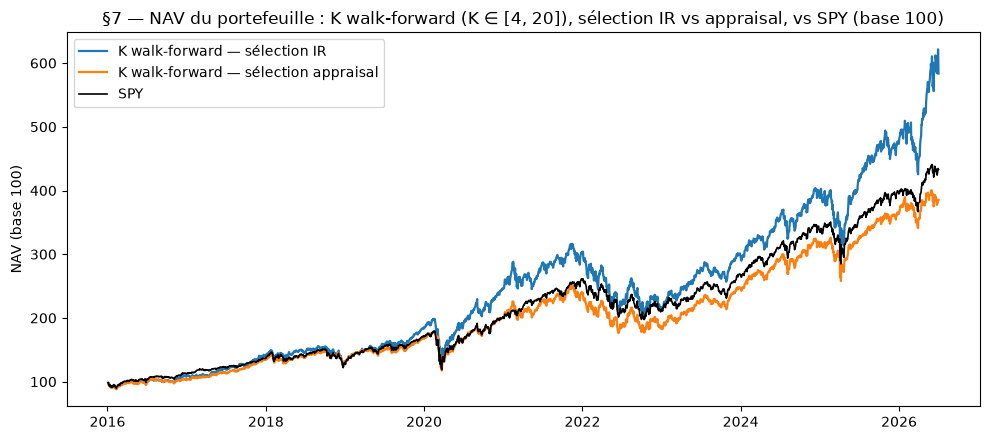

In [36]:
# FIGURE : NAV du portefeuille — K choisi en WALK-FORWARD (sélection IR vs appraisal) vs SPY (base 100)
nav_wf_ir = 100 * (1 + r_wfK_eq).cumprod()
nav_wf_ap = 100 * (1 + r_wfK_ap).cumprod()
idx = nav_wf_ir.index.union(nav_wf_ap.index)
nav_wf_sp = 100 * (1 + r_spy.reindex(idx).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_wf_ir, label="K walk-forward — sélection IR", lw=1.6)
plt.plot(nav_wf_ap, label="K walk-forward — sélection appraisal", lw=1.6)
plt.plot(nav_wf_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)")
plt.title(f"§7 — NAV du portefeuille : K walk-forward (K ∈ [{KS[0]}, {KS[-1]}]), sélection IR vs appraisal, vs SPY (base 100)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Et si on rééquilibre tous les 6 mois ?
Même logique qu'aux §5-§7, mais on **re-sélectionne 2× par an** : coupe au **30/06** et au **31/12**, on
tient le **semestre suivant**. Rien ne change au portefeuille des membres — seule la **cadence** de
sélection/tenue change, et l'évaluation passe à l'**excès par semestre** :
$$\mathrm{IR}_{\text{sem}}=\frac{\overline{x_{\text{sem}}}}{\sigma(x_{\text{sem}})},\qquad
t=\mathrm{IR}_{\text{sem}}\sqrt{n},\quad n\approx 22\ \text{semestres (au lieu de 11 ans)}.$$
Le seuil de significativité (unilatéral 5 %) passe donc à **$t>1{,}72$** (au lieu de 1,81). On refait
**tout** : top-4 (IR + appraisal) et choix de $K$ walk-forward, mais à 6 mois.

In [37]:
# --- Coupes SEMESTRIELLES : 30/06 & 31/12, classements point-in-time ; combinaison = moteur en parts du §6 ---
def classement_a_date(d, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """classement_a_fin, mais à une DATE de coupe quelconque (point-in-time strict <= d)."""
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        n_trades = int((wf_traded[bid] <= d).sum()); n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252); t = score * np.sqrt(n_days / 252)
        else:
            ab = alpha_beta(rr); score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, score=score))
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=["bioguide_id", "score"]))

cuts = [pd.Timestamp(y, m, dd) for y in range(2015, 2026) for (m, dd) in [(6, 30), (12, 31)]]
next_bound = lambda d: pd.Timestamp(d.year, 12, 31) if d.month == 6 else pd.Timestamp(d.year + 1, 6, 30)
clsmt6_ir = {d: classement_a_date(d, critere="ir")        for d in cuts}
clsmt6_ap = {d: classement_a_date(d, critere="appraisal") for d in cuts}

def eval_sem(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    sem = r.index.year.values * 2 + (r.index.month.values > 6).astype(int)
    e = pd.Series({s: ((1 + r[sem == s]).prod() - 1) - ((1 + b[sem == s]).prod() - 1) for s in sorted(set(sem))})
    n = len(e); ir = e.mean() / e.std(ddof=1)
    return dict(exces_an=2 * e.mean(), t=ir * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}", n=n)

def _ligne6(r):
    e = eval_sem(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_an"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

r_6m_ir = strategie_en_parts(4, "equal", "ir",        "6m")["r"]
r_6m_ap = strategie_en_parts(4, "equal", "appraisal", "6m")["r"]
print(f"coupes semestrielles prêtes | {len(cuts)} coupes | n semestres : IR={eval_sem(r_6m_ir)['n']}, appr={eval_sem(r_6m_ap)['n']}")

coupes semestrielles prêtes | 22 coupes | n semestres : IR=22, appr=22


In [38]:
# TOP-4 : rééquilibrage annuel vs tous les 6 mois, pour les 2 critères (seuil t : 1,81 -> 1,72)
print(f"top-4 : annuel ({len(yearly_excess(r_dr_eq))} années, seuil 1,81) vs 6 mois ({eval_sem(r_6m_ir)['n']} semestres, seuil 1,72) — 2 critères de sélection")
pd.DataFrame({
    "top-4 sél IR — annuel":        _ligne(r_dr_eq),
    "top-4 sél IR — 6 mois":        _ligne6(r_6m_ir),
    "top-4 sél appraisal — annuel": _ligne(r_ap_eq),
    "top-4 sél appraisal — 6 mois": _ligne6(r_6m_ap),
}).T.round(3)

top-4 : annuel (11 années, seuil 1,81) vs 6 mois (22 semestres, seuil 1,72) — 2 critères de sélection


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
top-4 sél IR — annuel,0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
top-4 sél IR — 6 mois,0.00432,0.137703,12/22,1.237727,-0.024558,-0.638371
top-4 sél appraisal — annuel,-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
top-4 sél appraisal — 6 mois,-0.050248,-2.000941,8/22,1.047842,-0.050651,-1.481435


In [39]:
# CHOIX DE K à 6 mois : séries-K semestrielles + K walk-forward (critère apparié comme §7)
R_K6_ir = {K: strategie_en_parts(K, "equal", "ir",        "6m")["r"] for K in KS}
R_K6_ap = {K: strategie_en_parts(K, "equal", "appraisal", "6m")["r"] for K in KS}

def k_walk_forward_6m(RbyK, score):
    parts = []
    for j, d in enumerate(cuts):
        if j == 0:
            k_star = 4                                   # pas d'historique de stratégie
        else:
            sc = {K: score(RbyK[K].loc[:d]) for K in KS}
            best = max(sc.values()); k_star = min(K for K in KS if sc[K] == best)
        idx = cal[(cal > d) & (cal <= next_bound(d))]
        parts.append(RbyK[k_star].reindex(idx).dropna())
    return pd.concat(parts).sort_index()

print("les 8 variantes — K=4 fixe / K walk-forward × sélection IR / appraisal × rééquilibrage annuel / 6 mois")
r_wfK6_ir = k_walk_forward_6m(R_K6_ir, score_ir)
r_wfK6_ap = k_walk_forward_6m(R_K6_ap, score_appr)
pd.DataFrame({
    "K=4 fixe (sél IR) — annuel":        _ligne(r_dr_eq),
    "K=4 fixe (sél IR) — 6 mois":        _ligne6(r_6m_ir),
    "K=4 fixe (sél appraisal) — annuel": _ligne(r_ap_eq),
    "K=4 fixe (sél appraisal) — 6 mois": _ligne6(r_6m_ap),
    "K-wf (sél IR) — annuel":            _ligne(r_wfK_eq),
    "K-wf (sél IR) — 6 mois":            _ligne6(r_wfK6_ir),
    "K-wf (sél appraisal) — annuel":     _ligne(r_wfK_ap),
    "K-wf (sél appraisal) — 6 mois":     _ligne6(r_wfK6_ap),
}).T.round(3)

les 8 variantes — K=4 fixe / K walk-forward × sélection IR / appraisal × rééquilibrage annuel / 6 mois


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR) — annuel,0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
K=4 fixe (sél IR) — 6 mois,0.00432,0.137703,12/22,1.237727,-0.024558,-0.638371
K=4 fixe (sél appraisal) — annuel,-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
K=4 fixe (sél appraisal) — 6 mois,-0.050248,-2.000941,8/22,1.047842,-0.050651,-1.481435
K-wf (sél IR) — annuel,0.040673,1.58412,7/11,1.16856,0.011487,0.445576
K-wf (sél IR) — 6 mois,0.021345,0.746801,12/22,1.173845,-0.003847,-0.143224
K-wf (sél appraisal) — annuel,-0.009955,-0.541885,5/11,0.973503,-0.005792,-0.289887
K-wf (sél appraisal) — 6 mois,-0.030255,-1.562113,10/22,1.021921,-0.0306,-1.351418


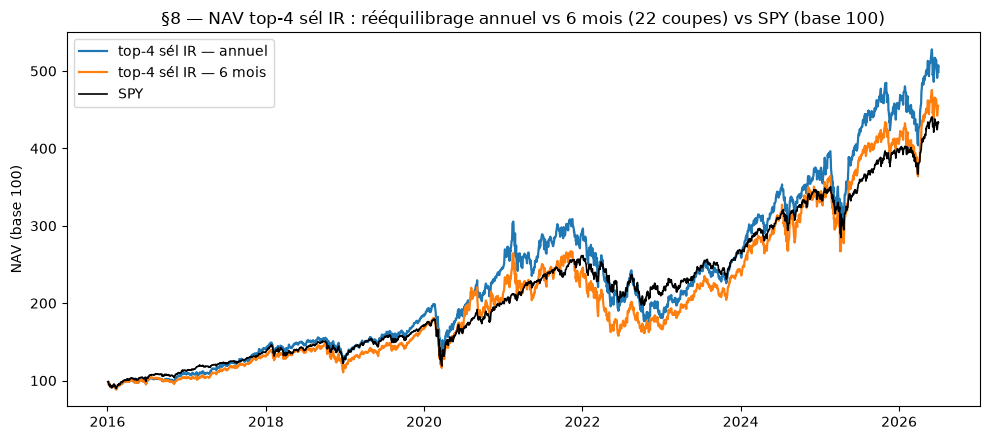

In [40]:
# FIGURE : NAV rééquilibrage annuel vs 6 mois (top-4 sél IR) vs SPY, base commune
start = max(r_dr_eq.index.min(), r_6m_ir.index.min())
a = r_dr_eq[r_dr_eq.index >= start]; m = r_6m_ir[r_6m_ir.index >= start]
nav9_an = 100 * (1 + a).cumprod(); nav9_6m = 100 * (1 + m).cumprod()
ix = nav9_an.index.union(nav9_6m.index)
nav9_sp = 100 * (1 + r_spy.reindex(ix).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav9_an, label="top-4 sél IR — annuel", lw=1.6)
plt.plot(nav9_6m, label="top-4 sél IR — 6 mois", lw=1.6)
plt.plot(nav9_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)"); plt.title(f"§8 — NAV top-4 sél IR : rééquilibrage annuel vs 6 mois ({len(cuts)} coupes) vs SPY (base 100)")
plt.legend(); plt.tight_layout(); plt.show()